# 03 · Data-Format Benchmarks — CSV vs Parquet vs Feather

**Phase goal:** choose how to *store* tabular data by measuring the size ↔ compression ↔ speed ↔ readability trade-off on **this** dataset, then feed the insight into the production pipeline.

A CSV is human-readable and opens in Excel, but it's large and stores no column types. Columnar binary formats (Parquet, Feather) are smaller and/or far faster and preserve dtypes — at the cost of readability.

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import pandas as pd, matplotlib.pyplot as plt
from car_pricing import config, data
df = data.clean(data.load_raw())
res = data.benchmark_formats(df, config.DATA_PROCESSED / '_bench')
tbl = (pd.DataFrame(res).T
        .assign(KB=lambda t: (t['bytes']/1024).round(0),
                vs_csv=lambda t: (t['bytes']/t.loc['csv','bytes']*100).round(1),
                write_ms=lambda t: (t['write_s']*1000).round(1),
                read_ms=lambda t: (t['read_s']*1000).round(1))
        [['KB','vs_csv','write_ms','read_ms']])
tbl

,KB,vs_csv,write_ms,read_ms
csv,1535.0,100.0,78.9,24.1
csv_gzip,290.0,18.9,308.3,26.3
csv_bz2,151.0,9.9,207.2,75.9
csv_xz,163.0,10.6,611.1,33.6
parquet_snappy,274.0,17.9,31.5,7.7
parquet_zstd,227.0,14.8,22.7,7.0
feather,867.0,56.5,11.5,5.0


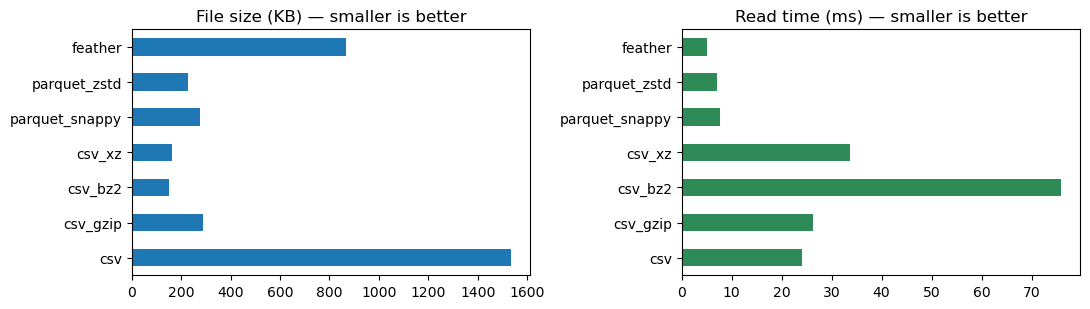

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11,3.2))
tbl['KB'].plot.barh(ax=ax[0], title='File size (KB) — smaller is better')
tbl['read_ms'].plot.barh(ax=ax[1], color='seagreen', title='Read time (ms) — smaller is better')
plt.tight_layout(); plt.show()

### Takeaways (see [`docs/FORMAT_BENCHMARKS.md`](../docs/FORMAT_BENCHMARKS.md))
- **`CSV + gzip`** — ~5× smaller than raw CSV, reads just as fast, pandas reads it directly. Best *low-friction* shrink for a git repo.
- **Parquet** — nearly as small **and ~3–4× faster to read**, keeps dtypes. The right default for real data pipelines and larger data.
- **Feather** — fastest read, but ~3× larger than Parquet; good for short-lived local hand-offs.
- **`CSV + bz2`** — smallest on disk but slowest to read (cold archival only).

> This project keeps `data/raw` as a plain CSV for transparency, and uses `data.write_dataframe(...)` to cache a **Parquet** copy for fast reloads during iterative modelling.